---
# Computergestützte Datenauswertung
**Institut für Experimentelle Teilchenphysik (ETP)** <br>
**Institut für Theorie der Kondensierten Materie (TKM)** <br>
Prof. Dr. Jan Kieseler (ETP), Dr. Joscha Ahäuser (ETP) <br>
Dr. Thorsten Chwalek (ETP), Dr. Andreas Poenicke (TKM) <br>
[ILIAS-Seite zum Kurs](https://ilias.studium.kit.edu/ilias.php?baseClass=ilrepositorygui&cmdNode=xs:mo&cmdClass=ilobjcoursegui&ref_id=2891557&item_ref_id=0) <br>
Sommersemester 2026 – Blatt 02 <br>
Abgabe: Montag, 11.05.2026 oder Dienstag, 12.05.2026 

---

Auf dem zweiten Übungsblatt beschäftigen Sie sich mit den Grundlagen der statistischen Datenauswertung.
In der [ersten Aufgabe](#Aufgabe1) setzen Sie sich mit einfachen statistischen Größen auseinander durch selbstständiges Implementieren der Ausdrücke aus der Vorlesung.
In der [zweiten Aufgabe](#Aufgabe2) bekommen Sie die Möglichkeit, den zentralen Grenzwertsatz noch einmal selbst in grafischer Weise zu vertiefen. 

---
# Aufgabe 1: Berechnung statistischer Größen <a id="Aufgabe1"></a>
---

In dieser Aufgabe implementieren Sie die Berechnung einiger der statistischen Größen aus der Vorlesung. 
Ziel dieser Übung ist es, die statistischen Größen, die aus einer Stichprobe (z. B. einer Messung) gewonnen werden, zu verinnerlichen: <mark>*arithmetisches Mittel*, *Stichprobenvarianz* und *Stichprobenstandardabweichung* </mark>(oft wird auch verkürzend von *Mittelwert*, *Varianz* und *Standardabweichung* gesprochen). Außerdem wiederholen Sie verschiedene Berechnungsweisen, die Sie in der Vorlesung kennengelernt haben.

In diesem Verzeichnis liegt Ihnen die Datei `numbers.txt` vor.
Diese Datei beinhaltet ganzzahlige Zufallszahlen im Bereich 0 bis 9.
Auf dem letzten Aufgabenblatt lernten Sie bereits die Bibliothek *NumPy* kennen und in der Vorlesung wurde Ihnen teilweise gezeigt, wie Sie mithilfe der Bibliothek die statistischen Größen *arithmetisches Mittel* ([`numpy.mean`](https://numpy.org/doc/stable/reference/generated/numpy.mean.html)), *Stichprobenvarianz* ([`numpy.var`](https://numpy.org/doc/stable/reference/generated/numpy.var.html)) und *Stichprobenstandardabweichung* ([`numpy.std`](https://numpy.org/doc/stable/reference/generated/numpy.std.html)) berechnen können.
Die folgende Jupyter-Zellen zeigt Ihnen, wie Sie die Daten in `numbers.txt` einlesen können und wie Sie mithilfe von *NumPy* die statistischen Größen berechnen lassen können.

**Anmerkung:**<br>
In vielen Fällen ist die <mark> *Stichprobenvarianz mit Bessel-Korrektur* </mark> der beste Schätzwert für die Varianz einer Wahrscheinlichkeitsverteilung aus einer Stichprobe, da diese erwartungstreu ist.
Eine einfache Herleitung für den Korrekturfaktor finden Sie auf [Wikipedia](https://de.wikipedia.org/wiki/Stichprobenvarianz_(Schätzfunktion)#Erwartungstreue).

In [3]:
import numpy as np

# Einlesen der Daten aus der Datei
numbers = np.loadtxt('numbers.txt', dtype=int)
N = len(numbers)
print(N, "Zahlen eingelesen: \n", numbers)

100 Zahlen eingelesen: 
 [0 0 3 6 0 2 0 3 1 0 6 3 1 8 8 5 1 8 3 6 4 9 8 8 8 3 1 8 6 3 6 7 1 6 2 3 0
 2 3 2 0 2 3 9 3 3 7 0 4 3 5 4 1 0 3 0 8 0 2 2 6 1 2 8 2 2 0 2 1 5 4 2 0 8
 7 9 1 9 4 9 4 5 2 7 7 9 9 1 1 3 8 5 5 7 3 2 8 6 6 6]


In [38]:
# NumPy-Funktionen
print("Statistische Größen mit NumPy:")
print("Arithmetisches Mittel        : ", np.mean(numbers))
print("Stichprobenvarianz           : ", np.var(numbers))
print("Stichprobenstandardabweichung: ", np.std(numbers))
print("Erwartungstreue Varianz      : ", np.var(numbers, ddof=1))


Statistische Größen mit NumPy:
Arithmetisches Mittel        :  3.99
Stichprobenvarianz           :  8.449900000000001
Stichprobenstandardabweichung:  2.9068711701759335
Erwartungstreue Varianz      :  8.535252525252526


**Arbeitsanweisung:**<br>
Schreiben Sie eine Python-Routine zur Berechnung der vier Größen, indem Sie die Definitionen der Größen, die in der Vorlesung für Stichproben kennengelernt haben, implementieren und nicht einfach die entsprechenden Bibliotheken wie bspw. mean direkt verwenden. Berechnen Sie die vier Größen mit dem Datensatz aus `numbers.txt` und vergleichen Sie Ihr Ergebnis mit den Werten, die Sie mithilfe von *NumPy* bereits erhalten haben.

**Hinweis:**<br>
Es bietet sich an, die einzelnen Berechnungen in Funktionen zu implementieren, die Sie wiederverwenden können.

In [47]:
import math

# Eigene Funktionen

def mean(values):
    """

    Args
    ----

    Returns
    -------


    """
    return np.sum(values)/len(values)

def variance(values):
    """
    Args
    ----

    Params
    ------

    """
    curr = np.array(values, dtype=float)
    return 1/(len(values)) * np.sum((curr - np.mean(values))**2)

def sigma(values: list):
    """
    Args
    ----

    Params
    ------
    """
    v = variance(values)

    if v < 0 or len(values):
        print("You data set leads to a variance less than zero!")

    return math.sqrt(variance(values))


def unbiased_variance(values):
    """
    Args
    ----

    Params
    ------

    """
    return 1/(len(values)-1) * np.sum((values - np.mean(values))**2)
    

In [50]:
# Statstische Definition für Stichproben
print("Statistische Größen mit eigener Defenition:")
m = mean(numbers)
print("Mittelwert: ", m)
v = variance(numbers)
print("Varianz: ", v)
print("Standardabweichung: ", sigma(numbers))
u_v = unbiased_variance(numbers)
print("Erwartungstreue Varianz", u_v)

Statistische Größen mit eigener Defenition:
Mittelwert:  3.99
Varianz:  8.449900000000001
You data set leads to a variance less than zero!
Standardabweichung:  2.9068711701759335
Erwartungstreue Varianz 8.535252525252528


Bestimmen Sie nun die Häufigkeit der einzelnen Zahlen in der Datei `numbers.txt`, d. h. füllen Sie einen `numpy.array` mit der jeweiligen Häufigkeit, mit der die Zahlen 0 bis 9 vorkommen. 
Das `numpy.array` enthält dann statt der ursprünglichen Datenmenge nur noch 10 Zahlen, die eine erheblich komprimiertere Version der ursprünglichen Daten darstellt.
In manchen Fällen der Datenauswertung werden Sie auf genau diesen Fall treffen, dass Ihnen nur die Häufigkeiten von Ereignissen in Ereignisklassen, die als *Bins* bezeichet werden, bekannt sind.

In [42]:
# Bestimmung der Häufigkeit
def num_frequency(value: list) -> list:
    """
    Args
    ----

    Returns
    -------
    """
    return ([np.sum(np.array(value) == k) for k in list(set(value))])

rng = np.random.default_rng()
nums = rng.integers(low=0, high=9, size=10)

Berechnen Sie anschließend den <mark>Mittelwert und die Varianz der Daten direkt aus der Häufigkeitsverteilung</mark>, wie Sie es bereits in der Vorlesung hergeleitet haben.
Vergleichen Sie mit den Ergebnissen, die Sie bisher erhalten haben.

In [51]:
# Eigene Funktionen aus Häufigkeit
def prepare_data(values:list)-> tuple[np.array]:
    """
   Args
   ----
   values :
   raw data (integers or floats expected) from the experiment

   Returns
   -------
   tuple[np.array]:
   collection contains at the first position the contained numbers and in the
   second the corresponding frequencies.
    """
    current = values

    #sort the given list in increasing order
    current.sort() #be aware this function does inplace muattaions and doesn't return anything

    #filter duplicates so just the raw numbers are contained in teh collection
    curr_nums = list(set(current))

    #compute the frequencies for each value
    frequencies = num_frequency(current)

    if len(curr_nums) != len(frequencies) or len(values) == 0:
        print("Preparation of data went wrong")
        return

    return np.array(curr_nums, dtype=float), np.array(frequencies, dtype=float)

def weighted_mean(values:list)-> list:
    """

    """
    nums, freqs = prepare_data(values)

    return np.sum(nums*freqs/np.sum(freqs))

def weighted_variance(values):
    """"""
    nums, freqs = prepare_data(values)
    x_mean = weighted_mean(values)

    denom = len(nums)-1

    if denom < 1:
        print("Input data set must have length greater than 1!")
        return None

    return np.sum(freqs * (np.array(nums) - np.array(x_mean))**2) / (np.sum(freqs)-1)

#Compare the mean and the variance coming from the 'normal' computation with the computation of the weighted formulas.
m_w = weighted_mean(numbers)
v_w = weighted_variance(numbers)

print(f"mean: {m}, weighted mean: {m_w}, mean/weighted_mean: {m/m_w if m_w != 0 else 0}")
#We use im both cases the unbiased variance because we consider our experimental data just as a set of data from the limitless possibilities of different experimental data sets.
print(f"variance: {u_v}, weighted variance: {v_w},variance/weighted_variance: {v/v_w if v_w != 0 else 0}")

mean: 3.99, weighted mean: 3.9899999999999998, mean/weighted_mean: 1.0000000000000002
variance: 8.535252525252528, weighted variance: 8.535252525252524,variance/weighted_variance: 0.9900000000000003


---
# Aufgabe 2: Zentraler Grenzwertsatz <a id="Aufgabe2"></a>
---

Der zentrale Grenzwertsatz ist in der statistischen Datenauswertung von wesentlicher Bedeutung und Bestandteil vieler Näherungen im frequentistischen Ansatz. 
In dieser Aufgabe sollen Sie selbst qualitativ anhand von zwei Beispielen die <mark>Konvergenz der Summe von $n$ unabhängigen Zufallszahlen</mark> beobachten.

Zur Wiederholung aus der Vorlesung: **Zentraler Grenzwertsatz**<br>
<mark>Im Grenzfall großer $n$ ist die (normierte) Summe von $n$ unabhängigen Zufallszahlen eine Zufallszahl, die einer Normalverteilung folgt</mark>.
$
z_n=\frac{\sum_{i=1}^n(x_i-\mu_i)}{\sqrt{\sum_{i=1}^n\sigma_i^2}}=\frac{y_n-\mathsf{E}[y_n]}{\sqrt{\mathsf{V}[y_n]}}
$
konvergiert für $n\to\infty$ gegen eine Standardnormalverteilung.

**Arbeitsanweisung:**<br>
Betrachten Sie die Summe $y_n$ von $n$ **gleichverteilten** Zufallszahlen $x_i$ im Intervall [0,1),  $y_n=\sum_{i=1}^{n}x_i$.
Berechnen Sie für $n=2,10, 100, 1000$ jeweils 100000 Werte von $z_n$.
Histogrammieren Sie die 100000 $z_n$ Werte und zeichnen Sie jeweils die Standardnormalverteilung (Normalverteilung mit $\mu=0$ und $\sigma=1$) mit in das Diagramm.
Achten Sie auf eine ausreichende Anzahl an Bins, damit der Vergleich aussagekräftig ist.

**Hinweis:**<br>
Für die Summe von $n$ gleichverteilten Zufallszahlen erhalten Sie $\mathsf{E}[y_n]=n/2$ und $\mathsf{V}[y_n]=n/12$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Funktion für die Normalverteilung
def Gaussian(x, mu=0., sigma=1.):
    return np.exp(-(x - mu)**2 / 2 / sigma**2) / np.sqrt(2*np.pi) / sigma

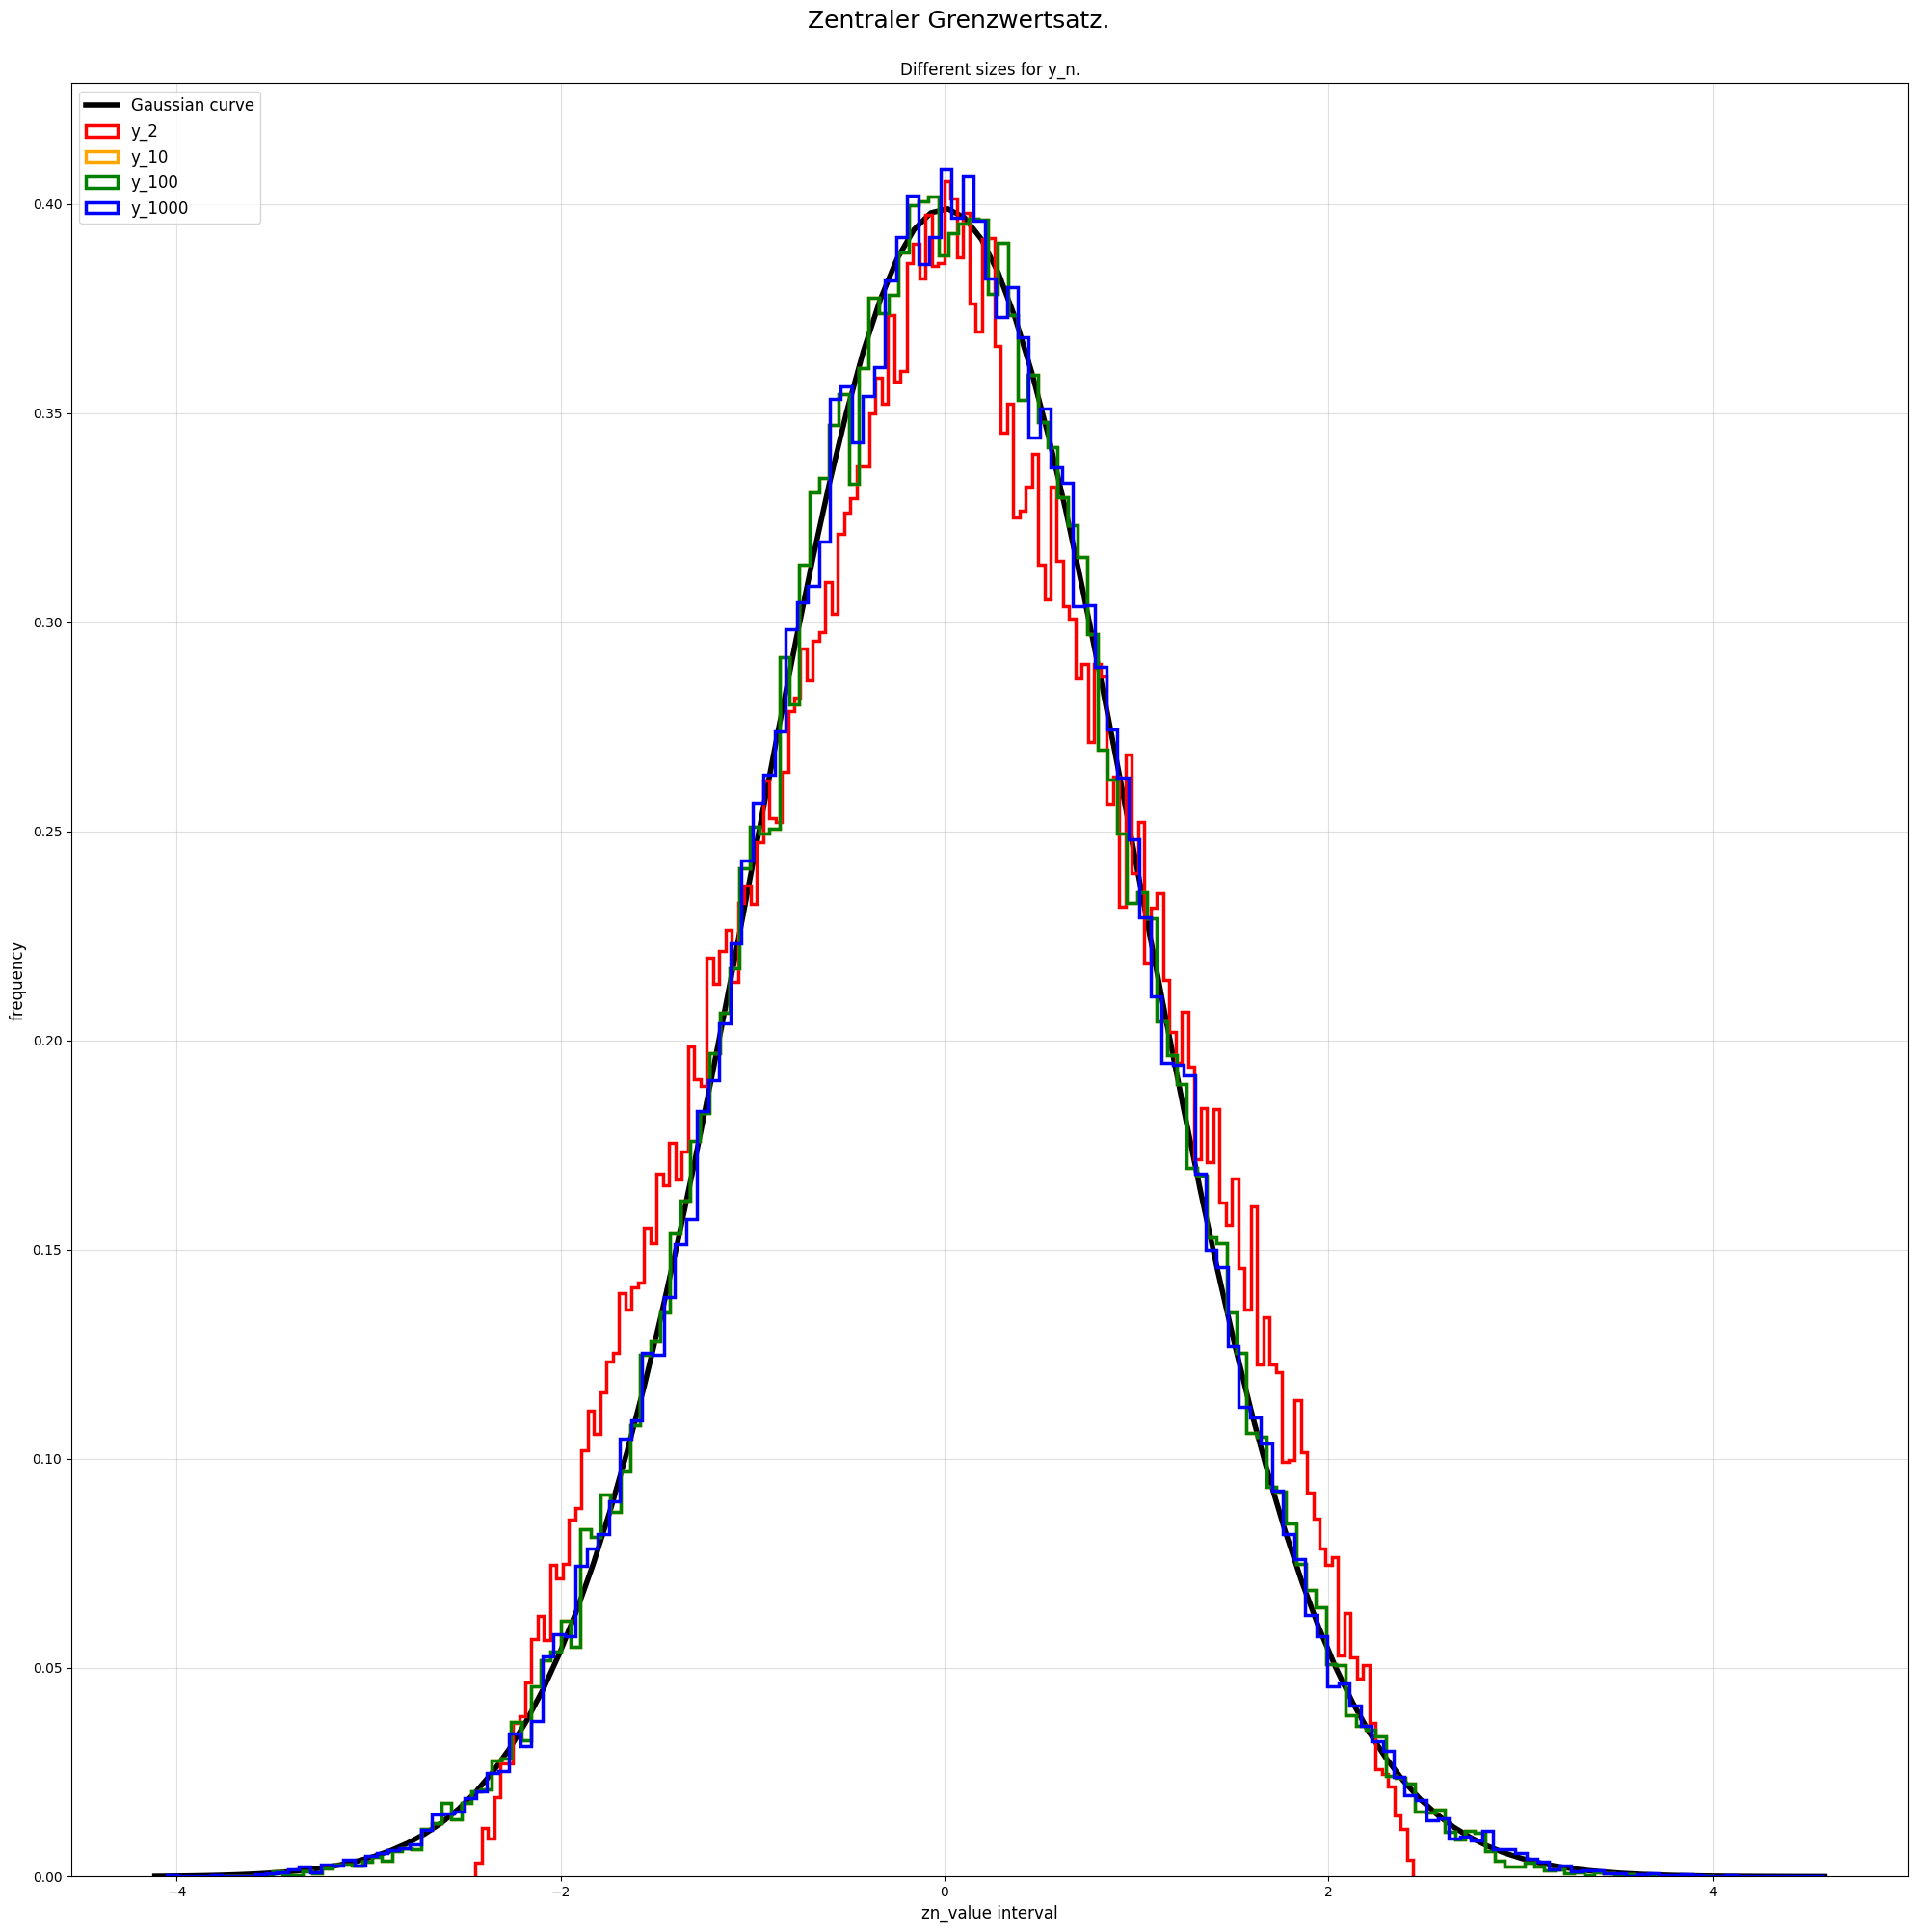

In [33]:
# Durchführung und Darstellung des Zufallexperiments

#gerate the random numbers
rng = np.random.default_rng()

#different amounts for the sum size
n_values = (2, 10, 100, 1000)

#amount of zn values that should be produced.
s = int(1e5)

#contains numpy array that stores the sums of the n different numbers produced with 100.000 repetitions
row_sums = list()

#Amount of bins.
n_bins = 450
colors = ('red', 'orange', 'green', 'blue')

#Define the expected values as well as the variance for each experiment.
expected_values = np.array([n/2 for n in n_values], dtype=float)
variances = np.array([n/12 for n in n_values], dtype=float)

for n in n_values:
    data = rng.random((s, n))
    row_sums.append(np.sum(data, axis=1))

#zentraler grenzwertsatz
f_y_a_b = lambda y, a, b: (y-a)/np.sqrt(b)

z_n_values = list()

for y_n_values, expected_val, variance in zip(row_sums,
                                              expected_values,
                                              variances):
    for y in y_n_values:
        z_n_values.append(f_y_a_b(y, expected_val, variance))

approaches = (z_n_values[:int(1e5)],
              z_n_values[int(1e5):int(2e5)],
              z_n_values[int(1e5):int(2e5)],
              z_n_values[int(2e5):int(3e5)],
              z_n_values[int(3e5):])

# Plot the different results the sum of n summands normal distributed in [0, 1)
fig, (ax) = plt.subplots(1, 1)

# Customize the figure in which the axes live.
fig.suptitle("Zentraler Grenzwertsatz.", y=1 ,fontsize=18)
fig.set_size_inches(20, 20)

# 1. Plot the Gaussian Normal Distribution as a curve
# Generate a smooth x-axis strictly min, max values of z_n
x_min, x_max = min(set(z_n_values)), max(set(z_n_values))
x_axis = np.linspace(x_min, x_max, 100)

# Plot the curve over the histogram
ax.plot(x_axis,
        Gaussian(x_axis, mu=0, sigma=1),
        color="black",
        linewidth=4,
        label="Gaussian curve")

#2 Plot the actual data for the computations of z_n
for z_n_value, label, c in zip(approaches,
                            n_values,
                            colors):

    ax.hist(list(z_n_value),
            bins=150,
            histtype='step',
            stacked=True,
            color=c,
            density=True,
            linewidth=2.5,
            label="y_"+str(label))

# Plot formatting
ax.set_aspect('auto')
ax.grid(alpha=0.4) #Slightly lighter grid
ax.set_xlabel("zn_value interval", fontsize=12)
ax.set_ylabel("frequency", fontsize=12)
ax.legend(loc="upper left", fontsize=12)
ax.set_title('Different sizes for y_n.')

#The task with 4 different plots for each size of y_n sepperately.
"""# Plot the different results the sum of n summands normal distributed in [0, 1)
fig, ((ax1), (ax2), (ax3), (ax4)) = plt.subplots(4, 1)

# Customize the figure in which the axes live.
fig.suptitle("Zentraler Grenzwertsatz.", y=1 ,fontsize=18)
fig.set_size_inches(20, 20)

print(set(approaches[0][:100]))

for ax, z_n_value, label in zip((ax1, ax2, ax3, ax4),
                                approaches,
                                n_values):

    # 1. Plot the actual simulated data
    ax.hist(list(z_n_value), bins=150,
            edgecolor='black', rwidth=0.8,
            color="orange", density=True, label=label)

    # 2. Plot the Gaussian Normal Distribution as a curve
    # Generate a smooth x-axis strictly bounded by current_bins
    x_min, x_max = min(set(z_n_values)), max(set(z_n_values))
    x_axis = np.linspace(x_min, x_max, 100)

    # Plot the curve over the histogram
    ax.plot(x_axis, Gaussian(x_axis, mu=0, sigma=1), color="blue", linewidth=1.5, label="Gaussian curve")

    # Plot formatting
    ax.set_aspect('auto')
    ax.grid(alpha=0.4) #Slightly lighter grid
    ax.set_xlabel("zn_value interval", fontsize=12)
    ax.set_ylabel("frequency", fontsize=12)
    ax.legend(loc="upper left", fontsize=12)"""

plt.tight_layout()
plt.show()







Wiederholen Sie nun die Zufallsexperimente mit einer Summe $y_n=\sum_{i=1}^{n} x_i$ von exponentiell verteilten Zufallszahlen $x_i$ für den Fall $\lambda = 1$. Verwenden Sie diesmal $\mathsf{E}[y_n]$ und $\mathsf{V}[y_n]$ nicht aus der Vorlesung, sondern berechnen Sie sie aus der PDF der Exponentialverteilung $f(x_i)=\lambda e^{-\lambda x_i}$ und den Definitionen von Erwartungswert und Varianz selbst.

Erhalten Sie das gleiche Ergebnis wie davor oder gibt es Unterschiede?


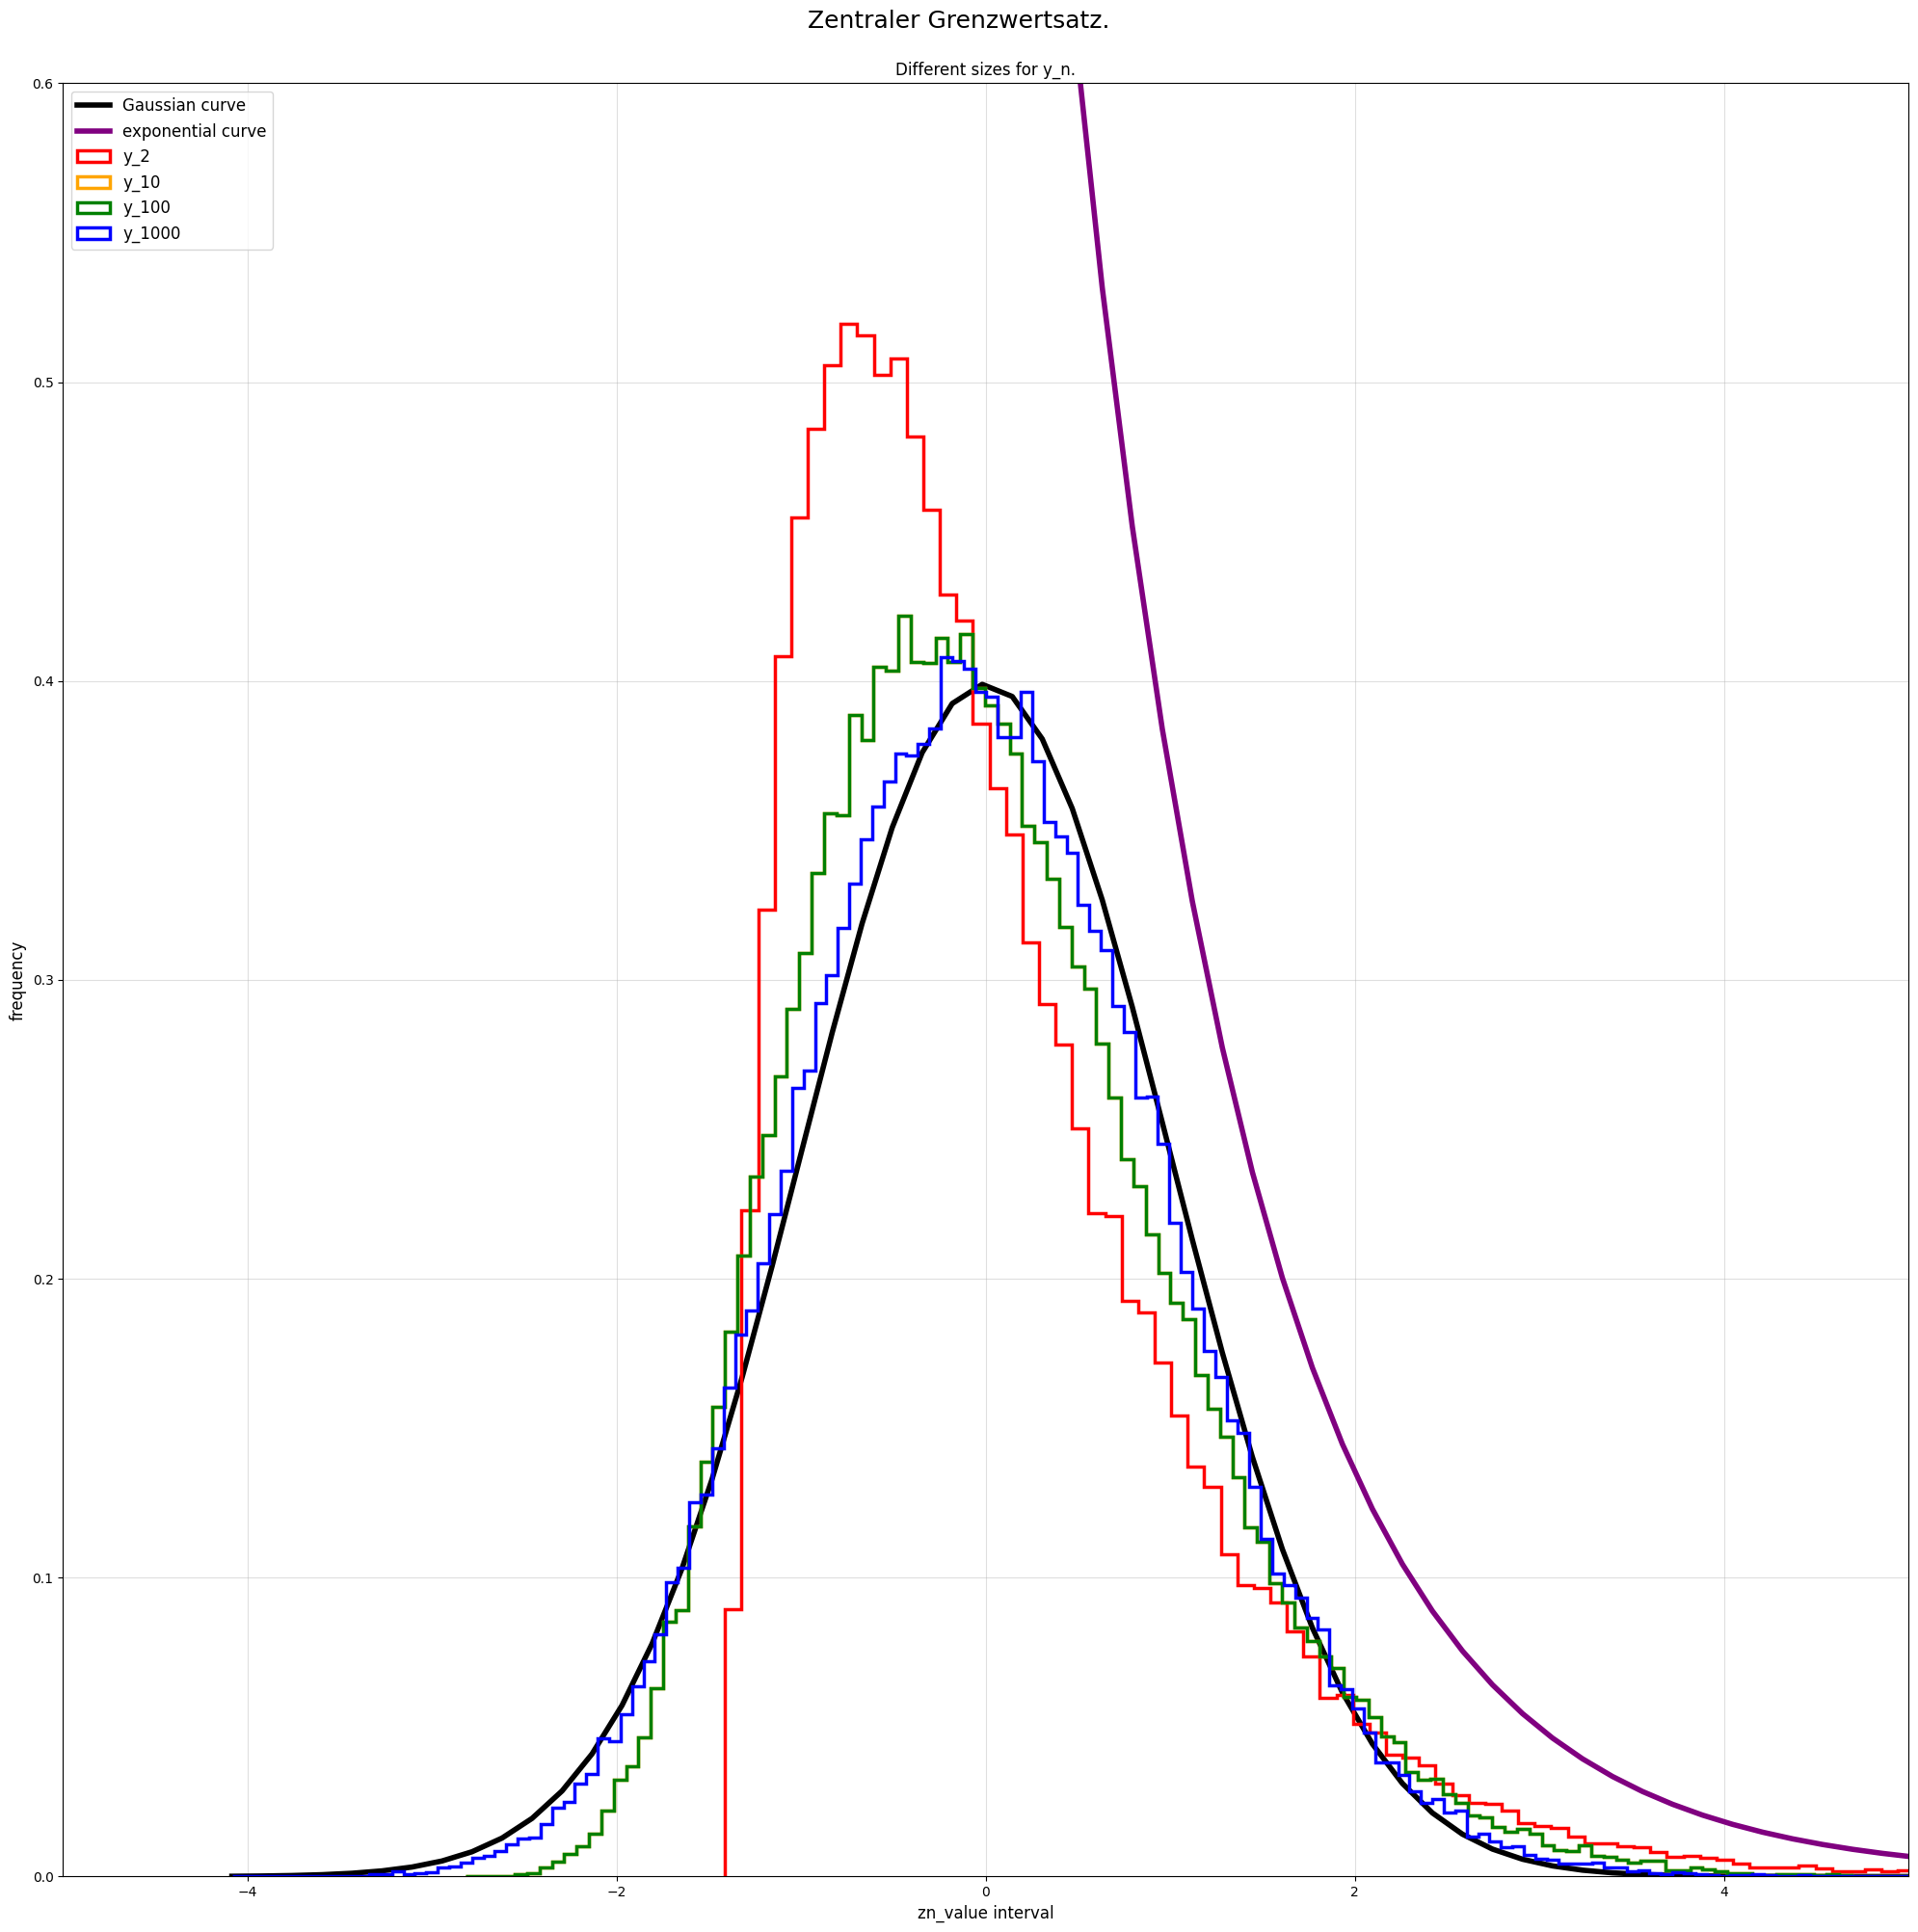

In [7]:
import numpy as np
import matplotlib.pyplot as plt
#different amounts for the sum size
n_values = (2, 10, 100, 1000)

#amount of zn values that should be produced.
s = int(1e5)

#contains numpy array that stores the sums of the n different numbers produced with 100.000 repetitions
row_sums = list()

#Amount of bins.
n_bins = 450
colors = ('red', 'orange', 'green', 'blue')

#generate exponential distributed data
lambda_param = 1
scale_param = lambda_param**(-1)

samples = 100000
random_nums = np.random.exponential(scale=scale_param, size=samples)

#zentraler grenzwertsatz
f_y_a_b = lambda y, a, b: (y-a)/np.sqrt(b)

#Define the expected values as well as the variance for exponetially distributed values.
#(use the linearity of expectations)
expected_values = [lambda_param**(-1) * n for n in n_values]
variances = [lambda_param**(-2) * n for n in n_values]

for n in n_values:
    data = np.random.exponential(scale=scale_param, size=(samples, n))
    row_sums.append(np.sum(data, axis=1))


z_n_values = list()

for y_n_values, expected_val, variance in zip(row_sums,
                                              expected_values,
                                              variances):
    for y in y_n_values:
        z_n_values.append(f_y_a_b(y, expected_val, variance))

approaches = (z_n_values[:int(1e5)],
              z_n_values[int(1e5):int(2e5)],
              z_n_values[int(1e5):int(2e5)],
              z_n_values[int(2e5):int(3e5)],
              z_n_values[int(3e5):])

# Plot the different results the sum of n summands normal distributed in [0, 1)
fig, (ax) = plt.subplots(1, 1)

# Customize the figure in which the axes live.
fig.suptitle("Zentraler Grenzwertsatz.", y=1 ,fontsize=18)
fig.set_size_inches(20, 20)

#Nevertheless the values are now exponentially distributed the sum of these generated numbess will morp into a perfectly symmetrical normal distribution (if teh sample amount is large enough)
x_min, x_max = min(set(z_n_values)), max(set(z_n_values))
x_axis = np.linspace(x_min, x_max, 100)

# Plot the curve over the histogram
ax.plot(x_axis,
        Gaussian(x_axis, mu=0, sigma=1),
        color="black",
        linewidth=4,
        label="Gaussian curve")

#Ploting the exponential function inside the plot. -> Seems to be not really meaningfull because the histogram shapes follow the normal distributin as expected.
#But the shapes of the sums for smal n's seems to have, nevertheless, in parts their originally exponetial decay in their shape. So the skewness of the original exponnetial function hasn't smoothed out yet for them which chanes for larger n.
ax.plot(x_axis,
        lambda_param*np.exp(-lambda_param*x_axis),
        color='purple',
        linewidth=4,
        label='exponential curve')

#2 Plot the actual data for the computations of z_n
for z_n_value, label, c in zip(approaches,
                            n_values,
                            colors):

    ax.hist(list(z_n_value),
            bins=150,
            histtype='step',
            stacked=True,
            color=c,
            density=True,
            linewidth=2.5,
            label="y_"+str(label))

#Lock the axis manually ecause teh compariso nexp function destroys the axes
ax.set_xlim(-5, 5)
ax.set_ylim(0,0.6) #normal curve peakes around 0.4 to 0.6

# Plot formatting
ax.set_aspect('auto')
ax.grid(alpha=0.4) #Slightly lighter grid
ax.set_xlabel("zn_value interval", fontsize=12)
ax.set_ylabel("frequency", fontsize=12)
ax.legend(loc="upper left", fontsize=12)
ax.set_title('Different sizes for y_n.')

plt.tight_layout()
plt.show()